In [1]:
from custom_nodes.comfywr_pytorch_renderkit.meshes.cuboid import Cuboid
from custom_nodes.comfywr_pytorch_renderkit.meshes.roofed_building import RoofedBuilding
from custom_nodes.comfywr_pytorch_renderkit.cameras.parametric_camera import ParametricCamera
from custom_nodes.comfywr_pytorch_renderkit.transforms.transform import Transform

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
import numpy as np
from PIL import Image
from pytorch3d.renderer import MeshRasterizer, RasterizationSettings, SoftSilhouetteShader, MeshRenderer

import matplotlib.pyplot as plt

In [3]:
import torch
import torch.nn.functional as F
from torchvision.transforms.functional import gaussian_blur

In [4]:
import torch
from pytorch3d.renderer import SoftSilhouetteShader, BlendParams, softmax_rgb_blend
from pytorch3d.renderer.mesh.shading import interpolate_face_attributes

from custom_nodes.comfywr_pytorch_renderkit.shaders.depth_with_soft_silhouette import SoftSilhouetteWithDepthShader
from custom_nodes.comfywr_pytorch_renderkit.shaders.normals_with_soft_silhouette import NormalsWithSoftSilhouetteShader
from custom_nodes.comfywr_pytorch_renderkit.utils.compute_normals import compute_normal_map, gaussian_blur

In [5]:
depth_path = "../ComfyUI/output/building_masked_depth_00006_.png"

invalid_depth_weight = 1e-6

depth_size = (256,256)

# Load depth map and mask
depth_img = np.array(Image.open(depth_path).resize(depth_size))
alpha = depth_img[:,:,-1]
depth = torch.from_numpy(depth_img[...,-2:]/255)
alpha = depth[:,:,-1]
dmin, dmax = torch.aminmax(depth.select(-1,0)[depth.select(-1,1) > 0])

normalized_depth = depth.clone()
normalized_depth.select(-1,0).sub_(dmin).div_(dmax-dmin).mul_(depth.select(-1,1)).sub_(1).add_(depth.select(-1,1), alpha=1)
normalized_depth.select(-1,0).clamp_min_(-invalid_depth_weight)

tensor([[-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06],
        [-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06],
        [-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06],
        ...,
        [-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06],
        [-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06],
        [-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06]], dtype=torch.float64)

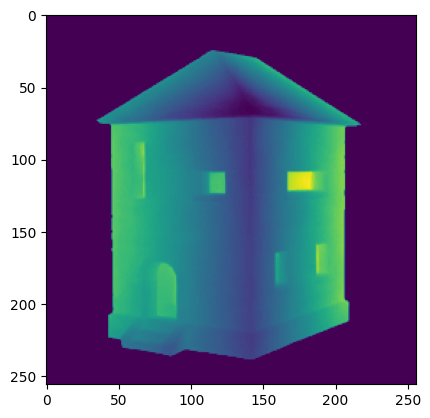

In [6]:
plt.imshow(normalized_depth.select(-1,0))

In [7]:
normalized_depth.amin()

tensor(-1.0000e-06, dtype=torch.float64)

In [8]:
ndepth, nalpha = normalized_depth.permute(2,0,1).float().unflatten(0,(-1,1,1))
normalmap = compute_normal_map(ndepth, nalpha, blur_kernel_size=3, blur_sigma=0.15)
normalmap = gaussian_blur(normalmap, kernel_size=5)
normalmap_rgb = normalmap.add(1).div_(2).mul_(nalpha)#.squeeze().permute(1,2,0)
# normalmap_rgb.select(1,1).clamp_max_(0.5)
normalmap_rgba = torch.cat([normalmap_rgb, nalpha], dim=1)

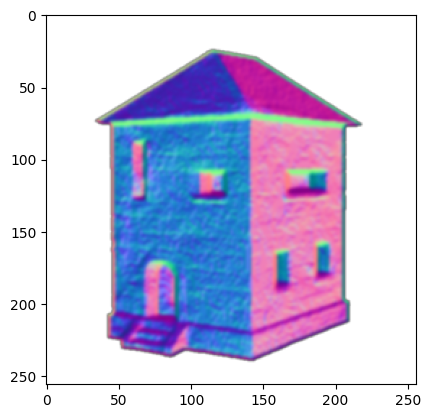

In [9]:
plt.imshow(normalmap_rgba.squeeze().permute(1,2,0))

In [10]:
normalmap_rgb.aminmax()

torch.return_types.aminmax(
min=tensor(0.),
max=tensor(0.9924))

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
depth = depth.to(device)

In [12]:
device

device(type='cuda')

In [13]:
# Rasterization settings for silhouette rendering  
sigma = 1e-6
raster_settings_silhouette = RasterizationSettings(
    image_size=depth.shape[:2], 
    blur_radius=np.log(1. / 1e-4 - 1.)*sigma, 
    faces_per_pixel=5, 
)

# Silhouette renderer 
renderer_normalized_depth = MeshRenderer(
    rasterizer=MeshRasterizer(
        raster_settings=raster_settings_silhouette
    ),
    shader=SoftSilhouetteWithDepthShader(normalize_depth=True, invalid_depth_weight=1e-6)
)

# Normal Map renderer
renderer_normalmap = MeshRenderer(
    rasterizer=MeshRasterizer(
        raster_settings=raster_settings_silhouette
    ),
    shader=NormalsWithSoftSilhouetteShader(camera_relative=True)
)

renderer_silhouette = MeshRenderer(
    rasterizer=MeshRasterizer(
        raster_settings=raster_settings_silhouette
    ),
    shader=SoftSilhouetteShader()
)

rasterizer_silhouette = MeshRasterizer(raster_settings=raster_settings_silhouette)

In [14]:
# Initialize models
transform = Transform(lock_scale=True, lock_rotation=True, lock_translation=True)

# sizes = torch.tensor([3., 2., 6.])
sizes = torch.tensor([3.5, 4, 4.5])
sizes /= sizes.max()

roof_size = (.05, 0.3, 0.2)
roof_size = (.5, 0.3, 0.5)

lr = 5e-4

fov = 30
distance = 3
# azimuth = 299.0
# elev = 13

azimuth = 35.0
elev = 3.0



camera = ParametricCamera(fov=fov, dist=distance, azim=azimuth, elev=elev, dist_range=(1.,20.)).to(device)
# cuboid = Cuboid(*sizes, transform=transform).to(device)
cuboid = RoofedBuilding(*sizes, roof_size=roof_size,transform=transform, export_without_roof=True).to(device)

# Rasterizer setup
raster_settings = RasterizationSettings(
    image_size=depth.shape[:2], blur_radius=0.0, faces_per_pixel=1
)
rasterizer = MeshRasterizer(raster_settings=raster_settings)

In [15]:
from custom_nodes.comfywr_pytorch_renderkit.shaders.depth_with_soft_silhouette import SoftSilhouetteWithDepthShader
from custom_nodes.comfywr_pytorch_renderkit.shaders.normals_with_soft_silhouette import NormalsWithSoftSilhouetteShader

mesh = cuboid()
cams = camera(device)
rendered_normalmap = renderer_normalmap(meshes_world=mesh, cameras=cams)
rendered_normalized_depth = renderer_normalized_depth(meshes_world=mesh, cameras=cams)

rendered_silhouette = renderer_silhouette(meshes_world=mesh, cameras=cams)

fragments = rasterizer_silhouette(meshes_world=mesh, cameras=cams)

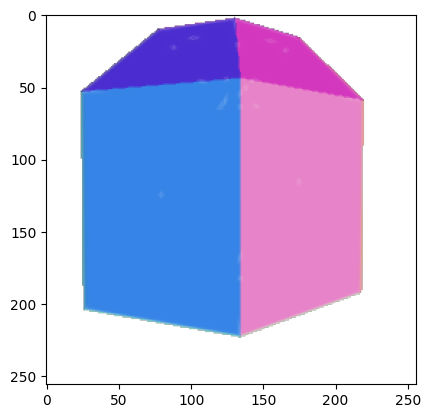

In [16]:
plt.imshow(rendered_normalmap.squeeze().detach().cpu())

torch.return_types.aminmax(
min=tensor(1., device='cuda:0', grad_fn=<NotImplemented>),
max=tensor(1., device='cuda:0', grad_fn=<NotImplemented>))


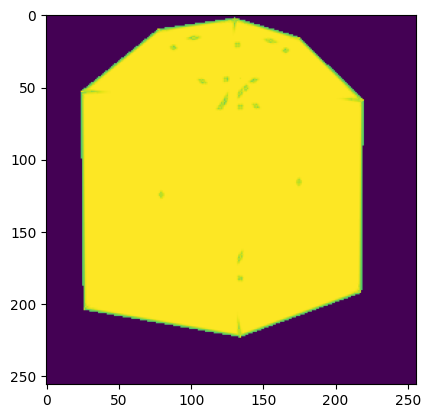

In [17]:
plt.imshow(rendered_silhouette.squeeze().detach().cpu()[...,-1])
print(rendered_silhouette[...,1].aminmax())

torch.Size([1, 256, 256, 2])


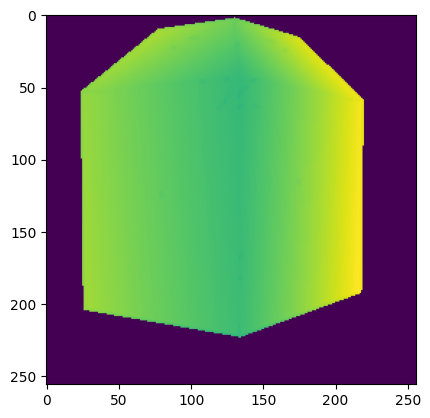

In [18]:
plt.imshow(rendered_normalized_depth[...,0].squeeze().detach().cpu())
print(rendered_normalized_depth.shape)

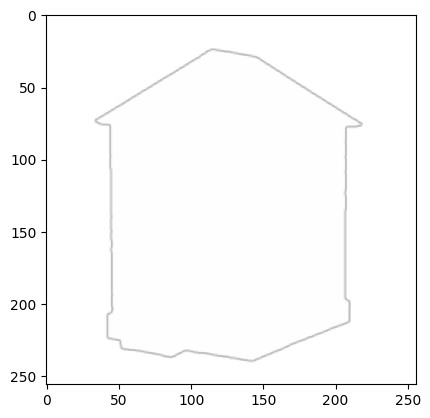

In [19]:
plt.imshow(nalpha.squeeze().unsqueeze(-1).mul(torch.tensor([1,1,1,1])))

In [20]:
from custom_nodes.comfywr_pytorch_renderkit.optimizations.early_stop_optimization import optimize_mesh_to_image

target_normalmap = normalmap_rgba.permute(0,2,3,1).float().to(device)

# SGD optimizer: translation (inside transform), sizes, and camera params
params = list(cuboid.parameters()) + list(camera.parameters())
# params = camera.parameters()
# optimizer = torch.optim.SGD(params, lr=lr, momentum=0.9)
optimizer = torch.optim.AdamW(params, lr=lr)

mesh, camera, losses, best_render = optimize_mesh_to_image(cuboid, camera, renderer_normalmap, target_normalmap, optimizer, early_stop_window = 150, early_stop_percent=1e-5, alpha_weight=4.0, device=device)
mesh, camera, further_losses, best_render = optimize_mesh_to_image(cuboid, camera, renderer_normalmap, target_normalmap, optimizer, early_stop_window = 200, early_stop_percent=1e-5, alpha_weight=4.0, device=device)
masked_target_normalmap = target_normalmap * best_render.select(-1,-1).unsqueeze(-1).gt(0)
params = list(cuboid.parameters())
optimizer = torch.optim.AdamW(params, lr=lr)
mesh, camera, masked_losses, masked_best_render = optimize_mesh_to_image(cuboid, camera, renderer_normalmap, masked_target_normalmap, optimizer, early_stop_window = 200, early_stop_percent=1e-5, alpha_weight=1.0, device=device)

 12%|██████████████▏                                                                                                        | 357/3000 [00:06<00:47, 55.75it/s]


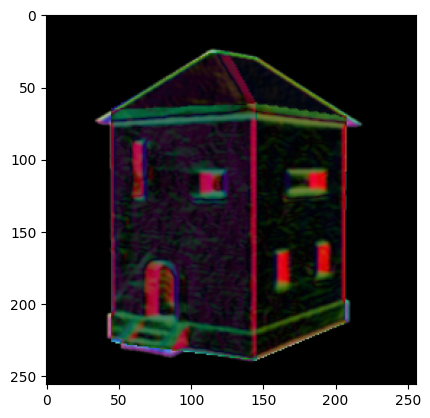

In [21]:
silhs = (masked_best_render - target_normalmap)[0,...,:-1].abs()
plt.imshow(silhs.detach().cpu())

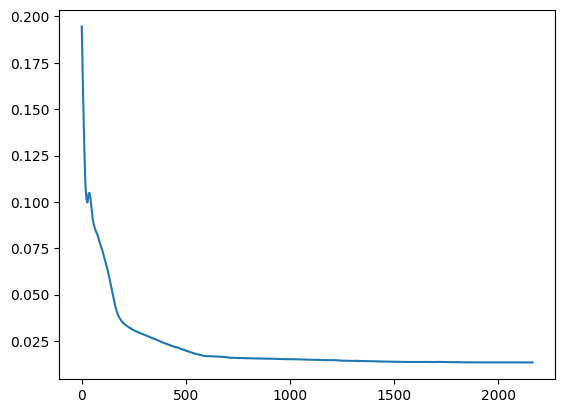

In [22]:
plt.plot(losses+further_losses)

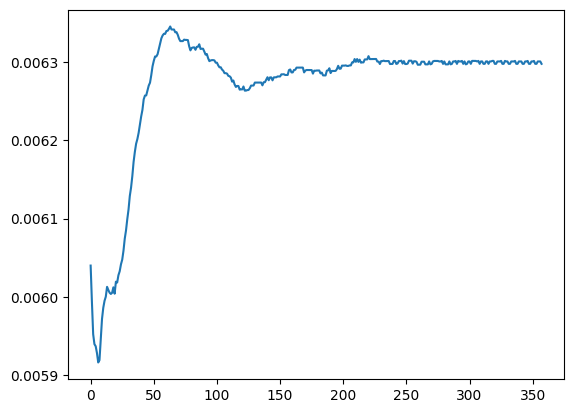

In [23]:
plt.plot(masked_losses)

In [24]:
denorm = lambda n, mn, mx: mn + n * (mx - mn)
camera.fov

tensor([24.6390], device='cuda:0')

In [25]:
camera.denorm(camera.dist_norm, camera.dist_min, camera.dist_max)

tensor([1.4423], device='cuda:0', grad_fn=<AddBackward0>)

In [26]:
camera.dist

tensor([3.8129], device='cuda:0')

In [27]:
camera.offset

Parameter containing:
tensor([[-0.0251,  0.1069, -0.0052]], device='cuda:0', requires_grad=True)

In [28]:
### cuboid.roof_size

In [29]:
cuboid.sizes

Parameter containing:
tensor([0.6887, 0.9824, 0.9054], device='cuda:0', requires_grad=True)

In [30]:
import torch.nn as nn

translation = cuboid.transform.translation.detach()

# Create an MSE loss criterion
criterion = nn.HuberLoss(reduction='mean')

with torch.no_grad():

    # transform = Transform(translation = cuboid.transform.translation.detach(), lock_scale=True, lock_rotation=True)
    # transform.translation[:] = cuboid.transform.translation.detach()
    new_cuboid = RoofedBuilding(*cuboid.sizes, roof_size=tuple(cuboid.roof_size)).to(device)

    new_target_normalmap = normalmap_rgba.permute(0,2,3,1).float().to(device)
    
    x = 0.038
    new_cuboid.sizes[1] -= x
    new_cuboid.transform.translation[...,1] -= x - 0.01
    new_cuboid.roof_size[1] += 0.068
    new_cuboid.roof_size[2] += 0.1
    # Render the cuboid
    mesh = new_cuboid()
    cams = camera(device)
    new_rendered = renderer_normalmap(meshes_world=mesh, cameras=cams)
    masked_target_normalmap = new_target_normalmap * new_rendered[...,-1].unsqueeze(-1).gt(0)
    new_loss = criterion(new_rendered, masked_target_normalmap)
    mesh = cuboid()
    old_rendered = renderer_normalmap(meshes_world=mesh, cameras=cams)
    masked_target_normalmap = new_target_normalmap * old_rendered[...,-1].unsqueeze(-1).gt(0)
    old_loss = criterion(old_rendered, masked_target_normalmap)

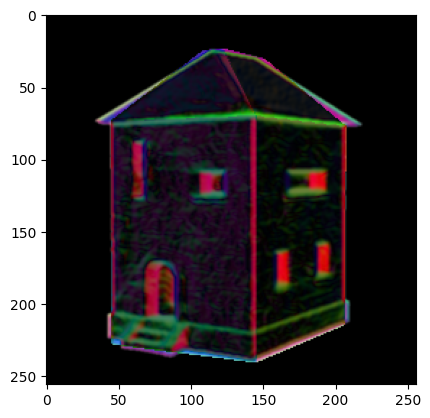

In [31]:
silhs = (new_rendered - target_normalmap)[0,...,:-1].abs()
plt.imshow(silhs.detach().cpu())

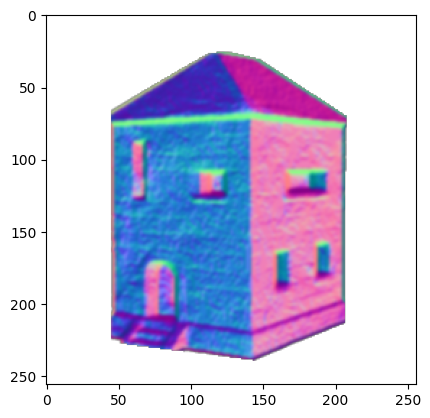

In [32]:
plt.imshow(masked_target_normalmap.squeeze().detach().cpu())

In [33]:
new_target_normalmap = normalmap_rgba.permute(0,2,3,1).float().to(device)

with torch.no_grad():
    mesh = new_cuboid()
    cams = camera(device)
    new_rendered = renderer_normalmap(meshes_world=mesh, cameras=cams)
    masked_target_normalmap = new_target_normalmap * new_rendered[...,-1].unsqueeze(-1).gt(0)
    new_loss = criterion(new_rendered, masked_target_normalmap)
    mesh = cuboid()
    old_rendered = renderer_normalmap(meshes_world=mesh, cameras=cams)
    masked_target_normalmap = new_target_normalmap * old_rendered[...,-1].unsqueeze(-1).gt(0)
    old_loss = criterion(old_rendered, masked_target_normalmap)

In [34]:
new_loss.item(),old_loss.item()

(0.006253920495510101, 0.005636220797896385)

In [35]:
c = cuboid.cuboid()

In [36]:
c.sizes

Parameter containing:
tensor([0.6887, 0.9824, 0.9054], device='cuda:0', requires_grad=True)

In [37]:
img_path = "../ComfyUI/input/wierd_windows_building.png"

depth_size = (128,128)

# Load depth map and mask
img = np.array(Image.open(img_path))

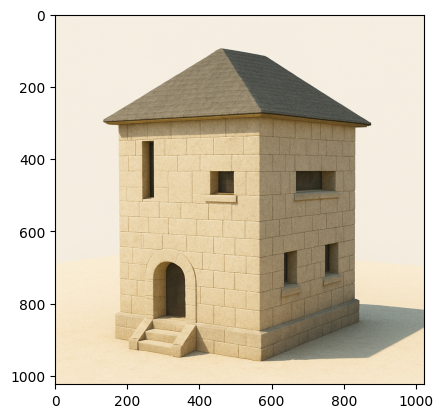

In [38]:
plt.imshow(img)

In [53]:
import xatlas
from pytorch3d.renderer import TexturesUV
from pytorch3d.structures import Meshes

v_np = cuboid().verts_packed().detach().cpu().numpy()
f_np = cuboid().faces_packed().detach().cpu().numpy()
atlas = xatlas.Atlas()
atlas.add_mesh(v_np, f_np)
chart_options = xatlas.ChartOptions()
# chart_options.max_iterations = 4
atlas.generate(chart_options=chart_options)
vmapping, ft_np, vt_np = atlas[0]

verts_uvs = torch.from_numpy(vt_np).to(device)          # (V_uv, 2)
faces_uvs = torch.from_numpy(ft_np).to(device).long() 

tex_map = torch.zeros(1024,1024,3).to(device).float()
texture = TexturesUV(
        maps=[tex_map],
        faces_uvs=[faces_uvs],
        verts_uvs=[verts_uvs]
    )

mesh = cuboid()
new_meshes = Meshes(verts=mesh.verts_list(),
                    faces=mesh.faces_list(),
                    textures=texture)

reference_image = torch.from_numpy(img/255).to(device).float()

In [48]:
from custom_nodes.comfywr_pytorch_renderkit.utils.reproject_visible_faces import reproject_visible_faces

tex_map = reproject_visible_faces(new_meshes, camera(device), reference_image=reference_image, replace_all=False)

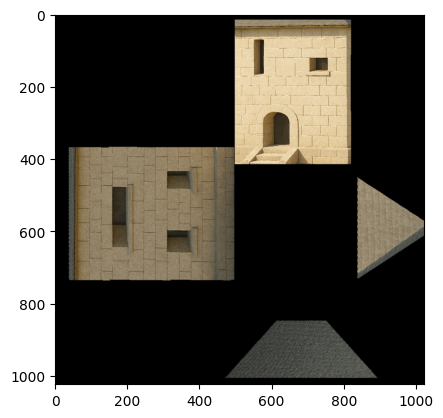

In [49]:
plt.imshow(tex_map.detach().cpu().numpy())

In [50]:
list(cuboid.parameters())

[Parameter containing:
 tensor([0.6887, 0.9824, 0.9054], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.1384, 0.2555, 0.3255], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([[1., 1., 1.]], device='cuda:0'),
 Parameter containing:
 tensor([[1., 0., 0., 0.]], device='cuda:0'),
 Parameter containing:
 tensor([[0., 0., 0.]], device='cuda:0')]